In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
from scipy import stats

In [3]:
df = pd.read_csv('spotify_history.csv')

In [4]:
df.head()

,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
0,2J3n32GeLmMjwuAzyhcSNe,2013-07-08 02:44:34,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False
1,1oHxIPqJyvAYHy0PVrDU98,2013-07-08 02:45:37,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False
2,487OPlneJNni3NWC8SYqhW,2013-07-08 02:50:24,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False
3,5IyblF777jLZj1vGHG2UD3,2013-07-08 02:52:40,web player,134022,Off To The Races,Lana Del Rey,Born To Die - The Paradise Edition,trackdone,clickrow,False,False
4,0GgAAB0ZMllFhbNc3mAodO,2013-07-08 03:17:52,web player,0,Half Mast,Empire Of The Sun,Walking On A Dream,clickrow,nextbtn,False,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149860 entries, 0 to 149859
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   spotify_track_uri  149860 non-null  object
 1   ts                 149860 non-null  object
 2   platform           149860 non-null  object
 3   ms_played          149860 non-null  int64 
 4   track_name         149860 non-null  object
 5   artist_name        149860 non-null  object
 6   album_name         149860 non-null  object
 7   reason_start       149717 non-null  object
 8   reason_end         149743 non-null  object
 9   shuffle            149860 non-null  bool  
 10  skipped            149860 non-null  bool  
dtypes: bool(2), int64(1), object(8)
memory usage: 10.6+ MB


In [6]:
df['ts'] = pd.to_datetime(df['ts'])

# Create additional time-based features
df['hour'] = df['ts'].dt.hour
df['day_of_week'] = df['ts'].dt.day_name()
df['month'] = df['ts'].dt.month_name()
df['year'] = df['ts'].dt.year
df['date'] = df['ts'].dt.date

In [7]:
df.ts

0        2013-07-08 02:44:34
1        2013-07-08 02:45:37
2        2013-07-08 02:50:24
3        2013-07-08 02:52:40
4        2013-07-08 03:17:52
                 ...        
149855   2024-12-15 23:06:19
149856   2024-12-15 23:06:21
149857   2024-12-15 23:06:22
149858   2024-12-15 23:06:23
149859   2024-12-15 23:06:25
Name: ts, Length: 149860, dtype: datetime64[ns]

In [8]:
df = df.drop('ts', axis=1)

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149860 entries, 0 to 149859
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   spotify_track_uri  149860 non-null  object        
 1   platform           149860 non-null  object        
 2   ms_played          149860 non-null  int64         
 3   track_name         149860 non-null  object        
 4   artist_name        149860 non-null  object        
 5   album_name         149860 non-null  object        
 6   reason_start       149717 non-null  object        
 7   reason_end         149743 non-null  object        
 8   shuffle            149860 non-null  bool          
 9   skipped            149860 non-null  bool          
 10  hour               149860 non-null  int32         
 11  day_of_week        149860 non-null  object        
 12  month              149860 non-null  object        
 13  year               149860 non-null  int32   

In [11]:
df.columns

Index(['spotify_track_uri', 'platform', 'ms_played', 'track_name',
       'artist_name', 'album_name', 'reason_start', 'reason_end', 'shuffle',
       'skipped', 'hour', 'day_of_week', 'month', 'year', 'date'],
      dtype='object')

In [12]:
df.describe().any()

ms_played    True
hour         True
year         True
date         True
dtype: bool

In [13]:
df.nunique()

spotify_track_uri    16527
platform                 6
ms_played            43082
track_name           13839
artist_name           4113
album_name            7948
reason_start            13
reason_end              15
shuffle                  2
skipped                  2
hour                    24
day_of_week              7
month                   12
year                    12
date                  2715
dtype: int64

In [14]:
df.duplicated().any()

np.True_

In [15]:
df.isna().sum()

spotify_track_uri      0
platform               0
ms_played              0
track_name             0
artist_name            0
album_name             0
reason_start         143
reason_end           117
shuffle                0
skipped                0
hour                   0
day_of_week            0
month                  0
year                   0
date                   0
dtype: int64

In [16]:
df['reason_start'].fillna('unknown', inplace=True)
df['reason_end'].fillna('unknown', inplace=True)

/var/folders/vl/z6gfc_1s4mbd9k5knjb6qm1c0000gn/T/ipykernel_58023/3537731829.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reason_start'].fillna('unknown', inplace=True)
/var/folders/vl/z6gfc_1s4mbd9k5knjb6qm1c0000gn/T/ipykernel_58023/3537731829.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

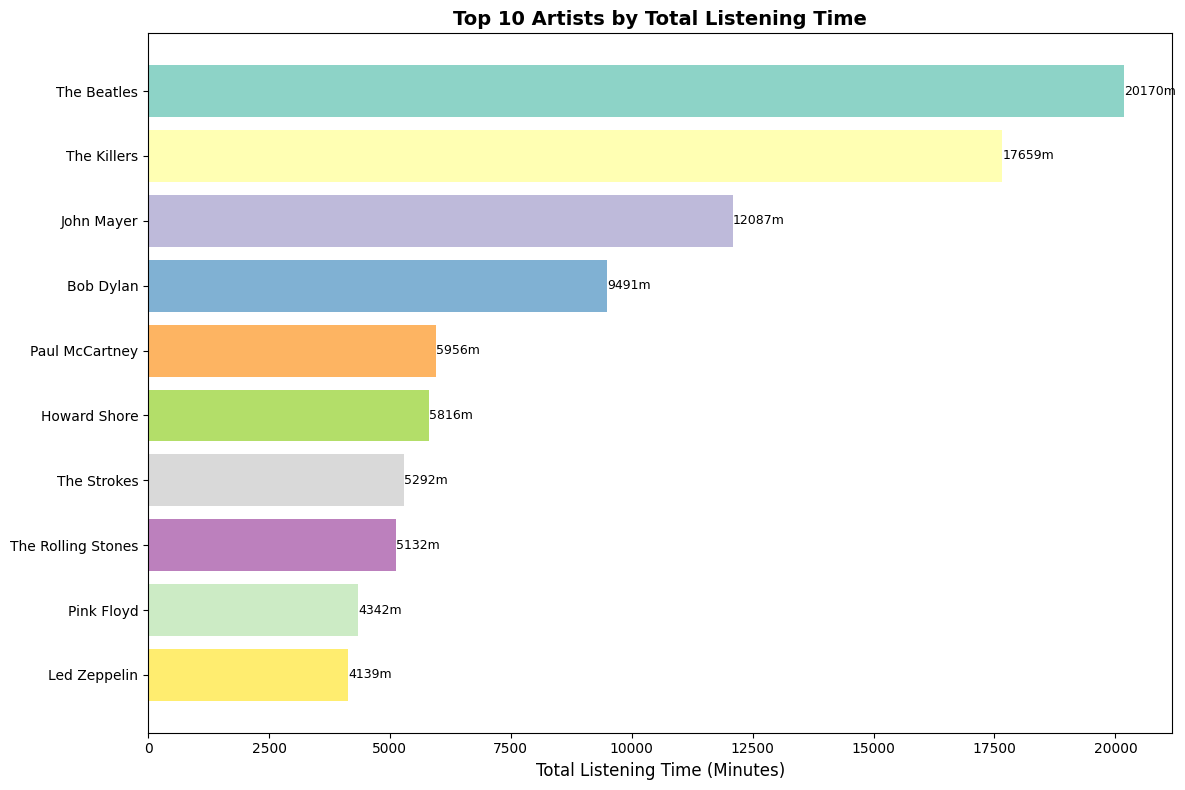

In [17]:
# Calculate total listening time per artist
artist_playtime = df.groupby('artist_name')['ms_played'].sum().sort_values(ascending=False)
top_artists = artist_playtime.head(10) / 1000 / 60  # Convert to minutes

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, 10))
bars = plt.barh(range(len(top_artists)), top_artists.values, color=colors)
plt.yticks(range(len(top_artists)), top_artists.index, fontsize=10)
plt.xlabel('Total Listening Time (Minutes)', fontsize=12)
plt.title('Top 10 Artists by Total Listening Time', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{top_artists.values[i]:.0f}m', va='center', fontsize=9)
plt.tight_layout()
plt.show()

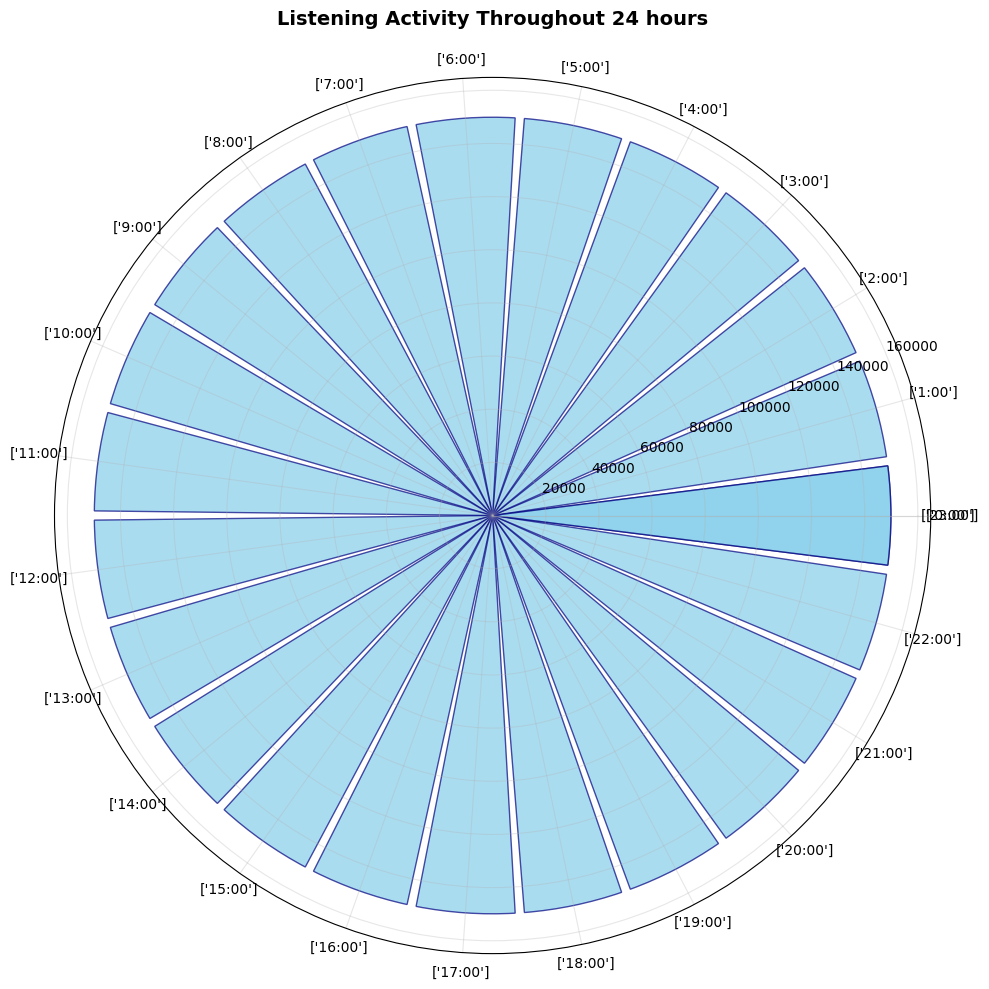

In [18]:
df['hour'] = pd.to_datetime(df['date']).dt.hour
hourly_activity = df.groupby('hour').size()

fig,ax = plt.subplots(figsize=(10,10),subplot_kw=dict(projection='polar'))
theta = np.linspace(0,2 * np.pi,24, endpoint='False')
bars = ax.bar(theta,hourly_activity.values, width=0.25, alpha=0.7, color='skyblue',edgecolor='navy')

ax.set_xticks(theta)
ax.set_xticklabels([f'{h}:00'] for h in range(24))
ax.set_ylim(0,hourly_activity.max() * 1.1)
ax.set_title('Listening Activity Throughout 24 hours', fontsize = 14, fontweight = 'bold',pad=20)
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

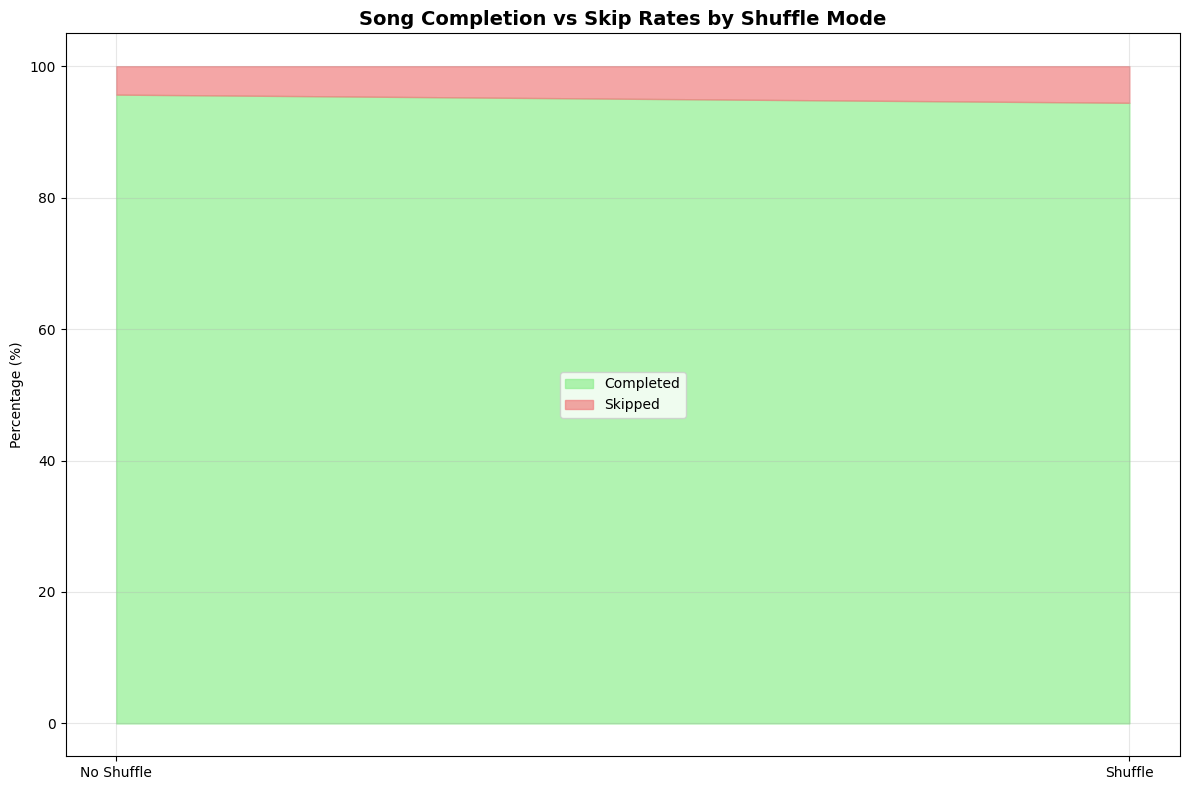

In [19]:
# Analyze skip behavior vs shuffle mode
skip_shuffle = df.groupby(['shuffle', 'skipped']).size().unstack(fill_value=0)
skip_rates = skip_shuffle.div(skip_shuffle.sum(axis=1), axis=0) * 100

# Create stacked area chart
fig, ax = plt.subplots(figsize=(12, 8))
x = ['No Shuffle', 'Shuffle']
y1 = skip_rates.loc[:, False].values
y2 = skip_rates.loc[:, True].values

ax.fill_between(range(len(x)), 0, y1, alpha=0.7, color='lightgreen', label='Completed')
ax.fill_between(range(len(x)), y1, y1 + y2, alpha=0.7, color='lightcoral', label='Skipped')
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x)
ax.set_ylabel('Percentage (%)')
ax.set_title('Song Completion vs Skip Rates by Shuffle Mode', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

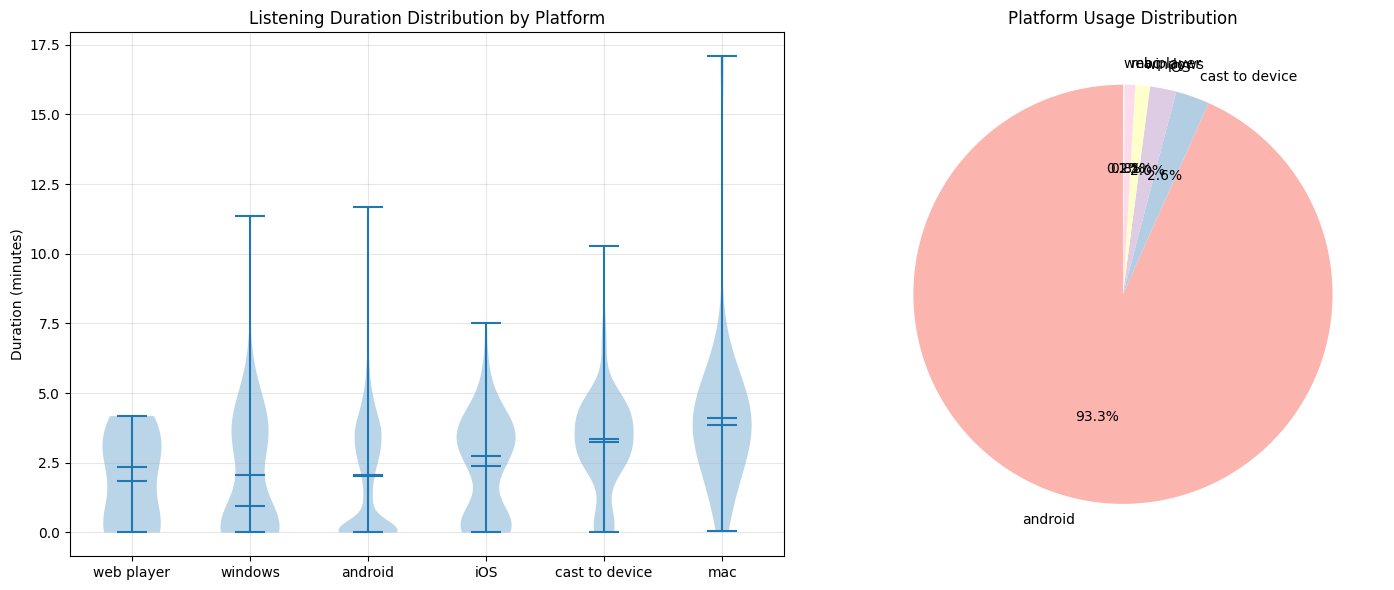

In [20]:
platform_stats = df.groupby('platform').agg({
    'ms_played': ['count', 'mean'],
    'spotify_track_uri': 'count'
}).round(2)

platform_stats.columns = ['Track Count', 'Avg Duration (ms)', 'Total Plays']
platform_stats['Avg Duration (min)'] = platform_stats['Avg Duration (ms)'] / 1000 / 60

# Create violin plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Violin plot for duration distribution
df_sample = df.sample(n=min(5000, len(df)))  # Sample for performance
parts = ax1.violinplot([df_sample[df_sample['platform'] == p]['ms_played'].values/1000/60 
                       for p in df['platform'].unique()], 
                      positions=range(len(df['platform'].unique())), 
                      showmeans=True, showmedians=True)
ax1.set_xticks(range(len(df['platform'].unique())))
ax1.set_xticklabels(df['platform'].unique())
ax1.set_ylabel('Duration (minutes)')
ax1.set_title('Listening Duration Distribution by Platform')
ax1.grid(True, alpha=0.3)

# Pie chart for platform usage
platform_counts = df['platform'].value_counts()
colors = plt.cm.Pastel1(np.linspace(0, 1, len(platform_counts)))
ax2.pie(platform_counts.values, labels=platform_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax2.set_title('Platform Usage Distribution')

plt.tight_layout()
plt.show()

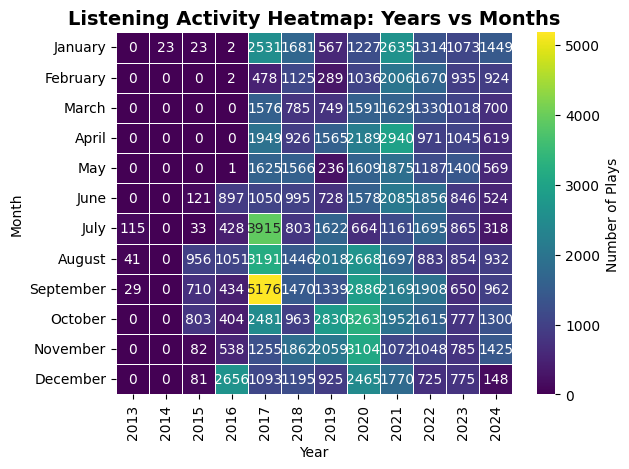

In [21]:
df['date'] = pd.to_datetime(df['date']).dt.date
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month_name()

monthly_year_data = df.groupby(['year', 'month']).size().reset_index(name='play_count')
pivot_data = monthly_year_data.pivot(index='month', columns='year', values='play_count').fillna(0)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December']
pivot_data = pivot_data.reindex(month_order)

plt.Figure(figsize=(12,8))
sns.heatmap(pivot_data, annot=True, fmt='.0f',cmap='viridis', cbar_kws={'label': 'Number of Plays'}, linewidths=0.5)
plt.title('Listening Activity Heatmap: Years vs Months',fontsize = 14, fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Month')

plt.tight_layout()
plt.show()

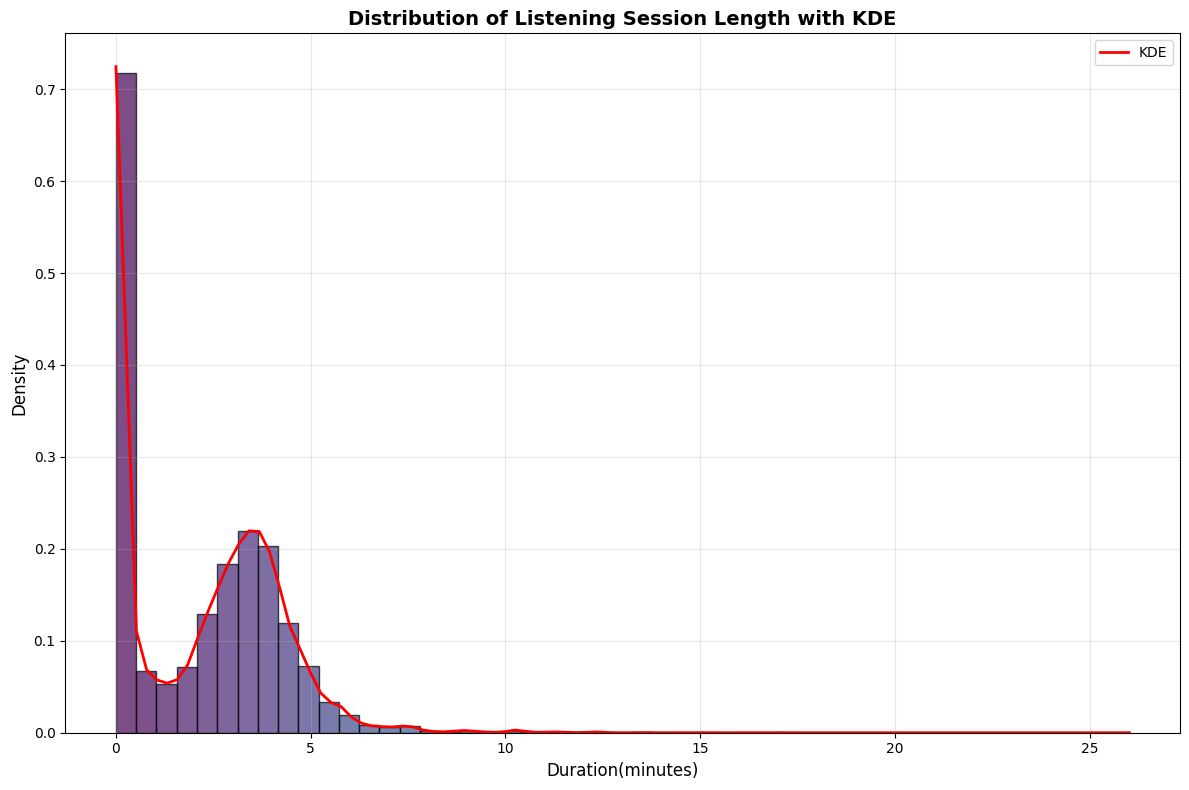

Mean duration:2.14 minutes
Median duration: 2.31 minutes


In [22]:
df['duration_minutes'] = df['ms_played'] / 1000 / 60

fig, ax = plt.subplots(figsize = (12,8))
n, bins, patches = ax.hist(df['duration_minutes'],bins = 50, density=True,alpha=0.7,color='lightblue',edgecolor='black')

from scipy.stats import gaussian_kde
kde = gaussian_kde(df['duration_minutes'].dropna())
x_range = np.linspace(df['duration_minutes'].min(), df['duration_minutes'].max(),100)
ax.plot(x_range,kde(x_range),'red',linewidth=2, label='KDE')

for i,patch in enumerate(patches):
    patch.set_facecolor(plt.cm.viridis(i/len(patches)))

ax.set_xlabel('Duration(minutes)',fontsize = 12)
ax.set_ylabel('Density', fontsize = 12)
ax.set_title('Distribution of Listening Session Length with KDE', fontsize = 14, fontweight ='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean duration:{df['duration_minutes'].mean():.2f} minutes")
print(f"Median duration: {df['duration_minutes'].median():.2f} minutes")

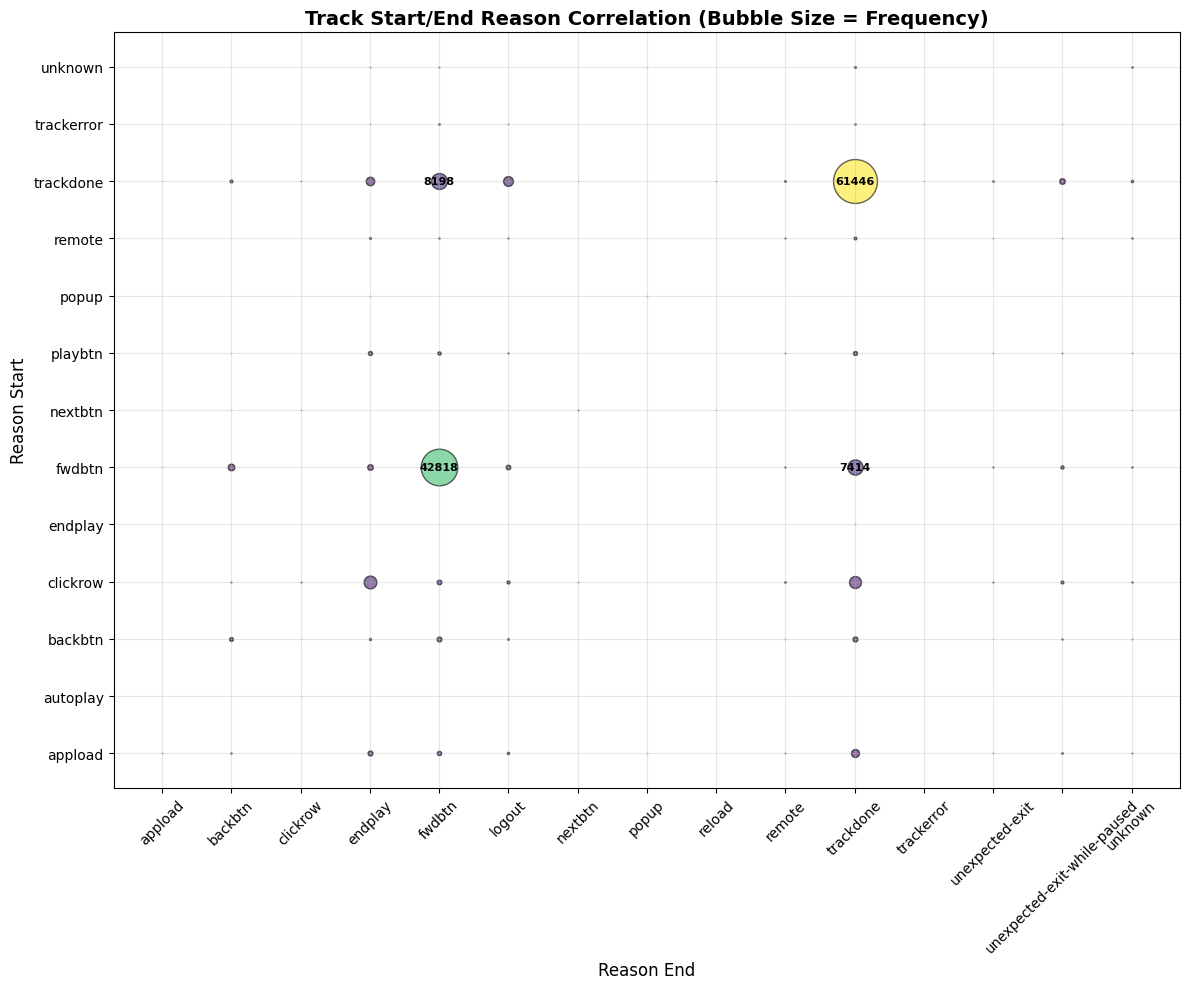

In [23]:
reason_combo = df.groupby(['reason_start','reason_end']).size().reset_index(name='count')
reason_pivot = reason_combo.pivot(index='reason_start',columns='reason_end',values='count').fillna(0)

fig, ax = plt.subplots(figsize=(12,10))
start_reasons = reason_pivot.index
end_reasons = reason_pivot.columns

for i, start in enumerate(start_reasons):
    for j, end in enumerate(end_reasons):
        count = reason_pivot.loc[start, end]
        if count > 0:
            size = (count / reason_pivot.max().max()) * 1000
            color = plt.cm.viridis(count / reason_pivot.max().max())
            ax.scatter(j,i,s=size, c=[color],alpha=0.6,edgecolors='black',linewidths=1)
            if count > reason_pivot.max().max() * 0.1:
                ax.annotate(f'{int(count)}',(j,i),ha='center',va='center',fontsize=8, fontweight='bold')

ax.set_xticks(range(len(end_reasons)))
ax.set_yticks(range(len(start_reasons)))
ax.set_xticklabels(end_reasons,rotation=45)
ax.set_yticklabels(start_reasons)
ax.set_xlabel('Reason End', fontsize = 12)
ax.set_ylabel('Reason Start', fontsize = 12)
ax.set_title('Track Start/End Reason Correlation (Bubble Size = Frequency)',fontsize = 14, fontweight='bold')
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

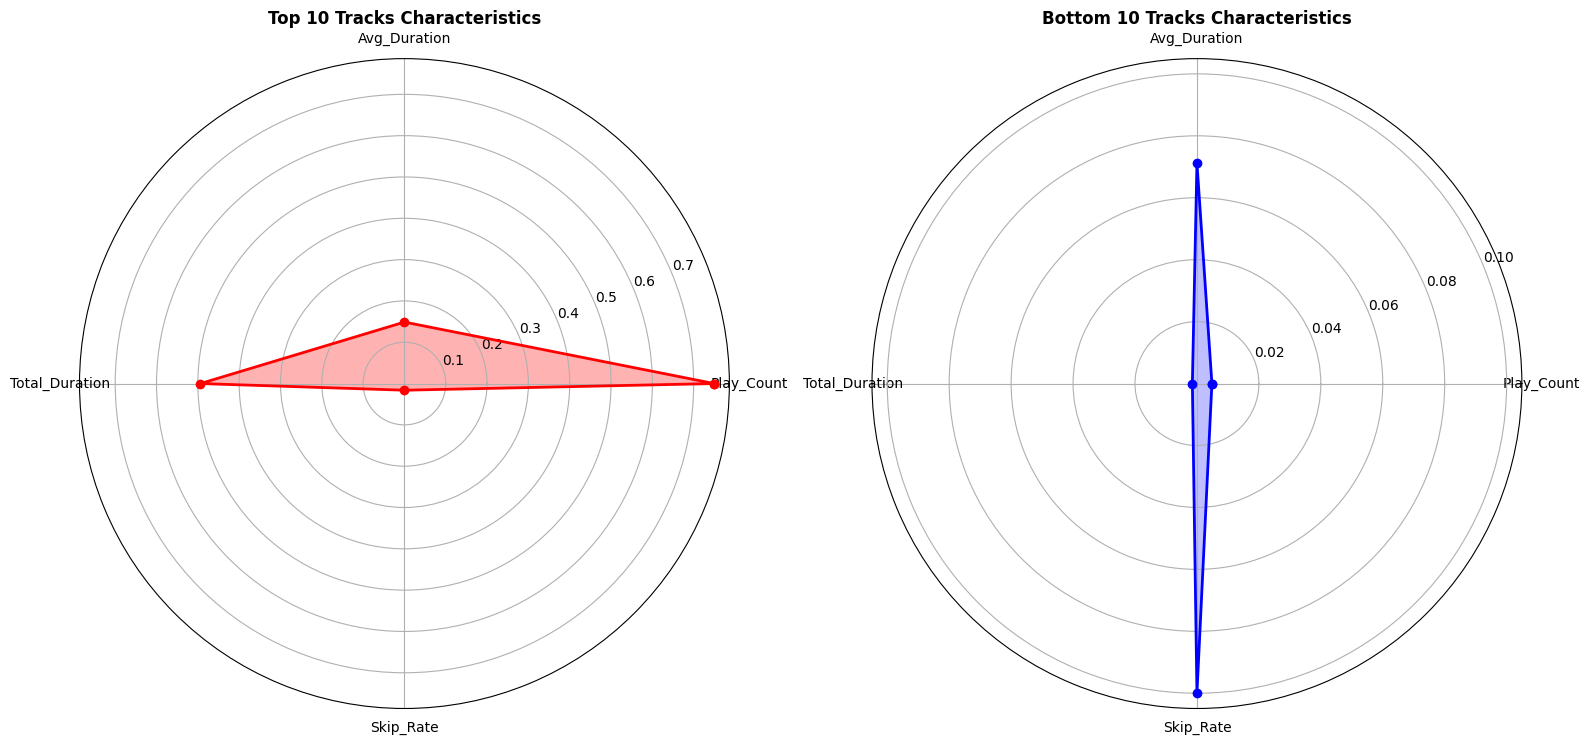

In [24]:
track_play_counts = df.groupby(['track_name','artist_name']).agg({
    'ms_played':['count','mean','sum'],
    'skipped':'mean'
}).round(3)

track_play_counts.columns = ['Play_Count','Avg_Duration','Total_Duration','Skip_Rate']
track_play_counts = track_play_counts.sort_values('Play_Count',ascending=False)

top_tracks = track_play_counts.head(10)
bottom_tracks = track_play_counts.tail(10)

categories = ['Play_Count','Avg_Duration','Total_Duration','Skip_Rate']
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(16,8),subplot_kw=dict(projection='polar'))

top_normalized = top_tracks[categories].mean()
bottom_normalized = bottom_tracks[categories].mean()

max_vals = track_play_counts[categories].max()
top_norm = top_normalized / max_vals
bottom_norm = bottom_normalized / max_vals

angles = np.linspace(0,2 * np.pi, len(categories),endpoint=False).tolist()
angles += angles[:1]

top_values = top_norm.tolist() + [top_norm.tolist()[0]]
bottom_values = bottom_norm.tolist() + [bottom_norm.tolist()[0]]

ax1.plot(angles, top_values, 'o-',linewidth=2, label='Top Tracks', color='red')
ax1.fill(angles, top_values, alpha = 0.3, color ='red')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)
ax1.set_title('Top 10 Tracks Characteristics', fontsize = 12, fontweight = 'bold')
ax1.grid(True)

ax2.plot(angles, bottom_values, 'o-', linewidth=2, label='Bottom Tracks', color='blue')
ax2.fill(angles, bottom_values, alpha=0.25, color='blue')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)
ax2.set_title('Bottom 10 Tracks Characteristics', fontsize=12, fontweight='bold')
ax2.grid(True)

plt.tight_layout()
plt.show()


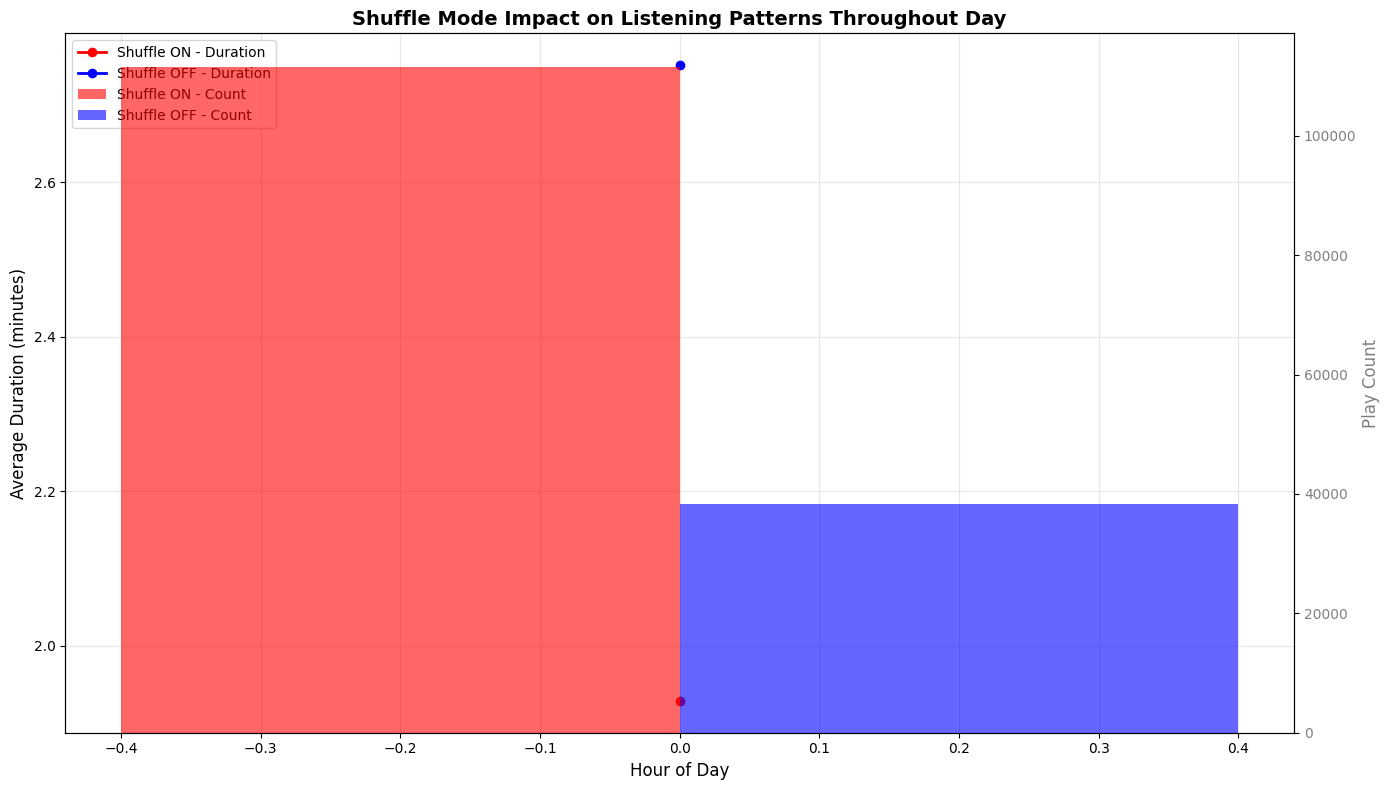

In [26]:
shuffle_time = df.groupby(['shuffle', 'hour']).agg({
    'ms_played': 'mean',
    'spotify_track_uri': 'count'
}).reset_index()

shuffle_time.columns = ['shuffle', 'hour', 'avg_duration', 'play_count']

fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot for shuffle=True
shuffle_true = shuffle_time[shuffle_time['shuffle'] == True]
shuffle_false = shuffle_time[shuffle_time['shuffle'] == False]

line1 = ax1.plot(shuffle_true['hour'], shuffle_true['avg_duration']/1000/60, 
                'o-', color='red', linewidth=2, markersize=6, label='Shuffle ON - Duration')
line2 = ax1.plot(shuffle_false['hour'], shuffle_false['avg_duration']/1000/60, 
                'o-', color='blue', linewidth=2, markersize=6, label='Shuffle OFF - Duration')

ax1.set_xlabel('Hour of Day', fontsize=12)
ax1.set_ylabel('Average Duration (minutes)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
bar1 = ax2.bar([h-0.2 for h in shuffle_true['hour']], shuffle_true['play_count'], 
              width=0.4, alpha=0.6, color='red', label='Shuffle ON - Count')
bar2 = ax2.bar([h+0.2 for h in shuffle_false['hour']], shuffle_false['play_count'], 
              width=0.4, alpha=0.6, color='blue', label='Shuffle OFF - Count')

ax2.set_ylabel('Play Count', color='gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='gray')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Shuffle Mode Impact on Listening Patterns Throughout Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
track_analysis = df.groupby('track_name').agg({
    'ms_played': ['mean', 'count'],
    'skipped': 'mean'
}).round(3)

track_analysis.columns = ['avg_duration', 'play_frequency', 'skip_rate']
track_analysis['duration_minutes'] = track_analysis['avg_duration'] / 1000 / 60

# Filter tracks with at least 5 plays for meaningful analysis
significant_tracks = track_analysis[track_analysis['play_frequency'] >= 5]

# Create 3D scatter plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Color mapping based on play frequency
colors = plt.cm.viridis(significant_tracks['play_frequency'] / significant_tracks['play_frequency'].max())

scatter = ax.scatter(significant_tracks['duration_minutes'], 
                    significant_tracks['skip_rate'], 
                    significant_tracks['play_frequency'],
                    c=colors, s=60, alpha=0.6, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Average Duration (minutes)', fontsize=12)
ax.set_ylabel('Skip Rate', fontsize=12)
ax.set_zlabel('Play Frequency', fontsize=12)
ax.set_title('3D Analysis: Duration vs Skip Rate vs Play Frequency', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, aspect=20)
cbar.set_label('Play Frequency', fontsize=10)

# Add trend analysis
ax.text2D(0.02, 0.98, f"Tracks analyzed: {len(significant_tracks)}", 
          transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

# Calculate correlations
correlation_matrix = significant_tracks[['duration_minutes', 'skip_rate', 'play_frequency']].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))